#### Simple Linear Regression

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline


In [2]:
df = pd.read_csv('../../data/height-weight.csv')
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


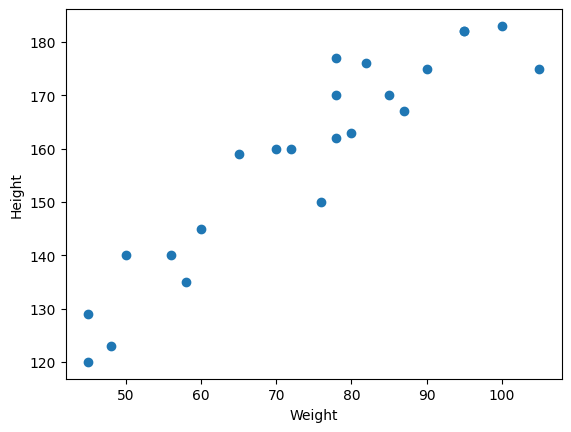

In [3]:
# scatter plot
plt.scatter(df['Weight'],df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')
plt.show()

In [4]:
#  finding correlation
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


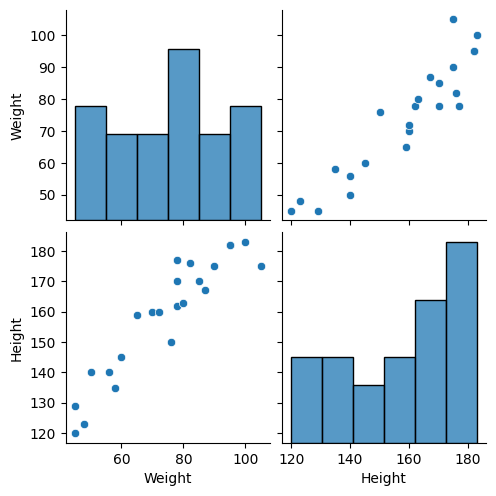

In [5]:
#  seaborn for visualization
import seaborn as sns
sns.pairplot(df)

In [6]:
# independent and independent features
df.head()
# independent features should be a dataframe always or a 2 dim array.
X=df[['Weight']]
# this should be in one dim array form.
Y=df['Height']

In [7]:
#  Train and Test Splitting.
from sklearn .model_selection import train_test_split

In [8]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.25, random_state=42)

In [9]:
X_train.shape

(17, 1)

In [10]:
#  Standardization
from sklearn.preprocessing import StandardScaler

In [11]:
scalar = StandardScaler()
X_train = scalar.fit_transform(X_train)

In [12]:
X_test = scalar.transform(X_test)
X_test

array([[ 0.33497168],
       [ 0.33497168],
       [-1.6641678 ],
       [ 1.36483141],
       [-0.45256812],
       [ 1.97063125]])

In [13]:
# Apply Linear Regression
from sklearn.linear_model import LinearRegression

# initialize the model
regression = LinearRegression()

In [14]:
# fit the input data
regression.fit(X_train,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
# coefficient of regression
print("Coefficient of regression: ", regression.coef_)
# intercept of regression
print("Intercept of regression are: ", regression.intercept_)

Coefficient of regression:  [17.2982057]
Intercept of regression are:  156.47058823529412


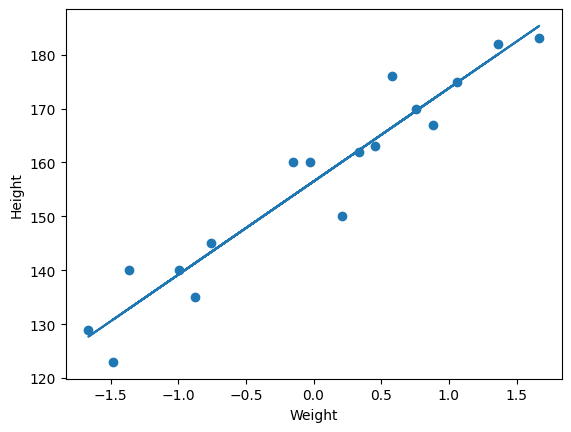

In [16]:
# plot the regression line
plt.xlabel('Weight')
plt.ylabel('Height')
plt.scatter(X_train,Y_train)
plt.plot(X_train,regression.predict(X_train))
plt.show()

In [17]:
# Prediction for test data
Y_pred = regression.predict(X_test)
Y_pred

array([162.26499721, 162.26499721, 127.68347133, 180.07972266,
       148.64197186, 190.55897293])

#### Prediction of test data.
1. prediction height output = intercept + coefficient * Weight
2. y_pred_test = 79.16324600728491 + ( 1.09209512 * Weight (X-test) )

In [18]:
# Performance matrices
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [19]:
# performance logging
mse = mean_squared_error(Y_test, Y_pred)
print("Mean Square error is: ", mse)
mae = mean_absolute_error(Y_test, Y_pred)
print("Mean Absolute error is: ", mae)
rmse = np.sqrt(mse)
print("Root Mean Square error is: ", rmse)


Mean Square error is:  114.84069295228699
Mean Absolute error is:  9.66512588679501
Root Mean Square error is:  10.716374991212605


# 📊 R² Score vs Adjusted R² Score

## 🔹 R² Score (Coefficient of Determination)

### 📌 Formula:
R² = 1 - (SS_res / SS_tot)

Where:
- SS_res = Σ(yᵢ - ŷᵢ)²  → Residual Sum of Squares  
- SS_tot = Σ(yᵢ - ȳ)²  → Total Sum of Squares  

---

### 💡 Intuition:
R² batata hai ki model data ko kitna achhe se explain kar raha hai.

- R² = 1 → Perfect prediction  
- R² = 0 → Model kuch bhi explain nahi kar raha  
- R² < 0 → Model random se bhi kharab  

---

### ⚠️ Problem with R²:
👉 Jab bhi tu model me new feature add karega  
R² kabhi decrease nahi hota (even useless features par bhi)

---

## 🔹 Adjusted R² Score

### 📌 Formula:
Adjusted R² = 1 - [ (1 - R²) * (n - 1) / (n - k - 1) ]

Where:
- n = number of data points  
- k = number of independent variables (features)  

---

### 💡 Intuition:
Adjusted R² model ko penalize karta hai unnecessary features ke liye.

👉 Sirf useful features add hone par hi score improve hota hai

---

## ⚔️ Key Difference

| Feature | R² Score | Adjusted R² |
|--------|--------|-------------|
| Feature addition | Always increases | May increase or decrease |
| Overfitting | Ignore karta hai | Penalize karta hai |
| Use case | Basic evaluation | Better for multiple features |

---

## 🎯 Final Takeaway

- R² → "Model kitna explain kar raha hai"  
- Adjusted R² → "Model + features dono kitne useful hain"  

👉 Always prefer Adjusted R² when working with multiple features

In [20]:
from sklearn.metrics import r2_score

In [21]:
score = r2_score(Y_test,Y_pred)
print("R2-Score is: ", score)

R2-Score is:  0.7360826717981276


In [22]:
# Adjusted R2-Score
1 - ( 1- score ) * (len(Y_test) -1)/(len(Y_test)-X_test.shape[1]-1)

0.6701033397476595

In [ ]:
# %pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


c:\Users\dpk41\OneDrive\Docs\Udemy Python\LinearRegression\PyProjects\.venv\Scripts\python.exe: No module named pip


# 📈 Ordinary Least Squares (OLS) Linear Regression

## 🔹 What is OLS?

Ordinary Least Squares (OLS) is a method used in Linear Regression to find the best-fitting line by minimizing the error between actual and predicted values.

👉 Goal: Find parameters (coefficients) that minimize prediction error.

---

## 🔹 Linear Regression Equation

y = β₀ + β₁x₁ + β₂x₂ + ... + βₖxₖ + ε

Where:
- y = dependent variable  
- x₁, x₂, ..., xₖ = independent variables  
- β₀ = intercept  
- β₁, β₂, ..., βₖ = coefficients  
- ε = error term  

---

## 🔹 Objective of OLS

OLS minimizes the **Residual Sum of Squares (RSS)**:

RSS = Σ(yᵢ - ŷᵢ)²

Where:
- yᵢ = actual value  
- ŷᵢ = predicted value  

👉 The best line = one that minimizes total squared error.

---

## 🔹 How OLS Works (Intuition)

- Model predicts values using current coefficients  
- Calculates error (difference between actual & predicted)  
- Squares the error (to avoid negatives)  
- Adjusts coefficients to minimize total error  

👉 Final result: Best-fit line

---

## 🔹 Key Assumptions of OLS

1. Linearity → Relationship between X and y is linear  
2. Independence → Observations are independent  
3. Homoscedasticity → Constant variance of errors  
4. No multicollinearity → Features should not be highly correlated  
5. Normality of errors → Residuals should be normally distributed  

---

## 🔹 Advantages

- Simple and easy to understand  
- Interpretable coefficients  
- Works well for linear relationships  

---

## 🔹 Limitations

- Sensitive to outliers  
- Assumes linear relationship  
- Performs poorly if assumptions are violated  

---

## 🔹 OLS vs Gradient Descent

| Feature | OLS | Gradient Descent |
|--------|-----|----------------|
| Approach | Analytical (closed-form) | Iterative optimization |
| Speed | Fast for small data | Better for large data |
| Accuracy | Exact solution | Approximate solution |

---



In [25]:
import numpy as np
import statsmodels.api as sm

# Sample Data
X = np.array([1, 2, 3, 4, 5])   # Independent variable
Y = np.array([2, 4, 5, 4, 5])   # Dependent variable

# Add constant (intercept β0)
X = sm.add_constant(X)

# Build Model
model = sm.OLS(Y, X)

# Train Model
results = model.fit()

# Print Summary
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.600
Model:                            OLS   Adj. R-squared:                  0.467
Method:                 Least Squares   F-statistic:                     4.500
Date:                Tue, 05 May 2026   Prob (F-statistic):              0.124
Time:                        20:17:35   Log-Likelihood:                -5.2598
No. Observations:                   5   AIC:                             14.52
Df Residuals:                       3   BIC:                             13.74
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.2000      0.938      2.345      0.1

c:\Users\dpk41\OneDrive\Docs\Udemy Python\LinearRegression\PyProjects\.venv\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


In [ ]:
# Now dump the model using pickle
# specify the path where you want to save the model
# also specify the input value it required to predict the output.
import pickle
# pickle.dump(regression, open('../../models/LinearRegression/simple_linear_regression_model.pkl', 'wb'))

# load the model
model = pickle.load(open('../../models/LinearRegression/simple_linear_regression_model.pkl', 'rb'))
model.predict([[50]])

# i want to build a web page for this model now give me the parameter or input it take to predict output.
# The model takes a single input parameter which is 'Weight' to predict the output 'Height'. So, the input parameter for the model is 'Weight'.
# example input: 50 (Weight in kg)

array([1021.38087345])